In [1]:
import os
import cv2
import mahotas
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from skimage.feature import local_binary_pattern
from concurrent.futures import ThreadPoolExecutor


In [2]:
# FULLY AUTONOMOUS EXTRACTION NODES

# 1. Applying Contour Fourier Descriptors to get Macro-Shape
def cfd(img):
    """
    Isolates the shape and converts the boundary into a frequency signal.
    """
    # Self-contained preprocessing
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(img_gray, 1, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour = max(contours, key=cv2.contourArea) if contours else None
    
    if contour is None:
        return np.zeros(32).tolist()
    
    # 1D Fast Fourier Transform on the boundary coordinates
    comp_contour = contour[:, 0, 0] + 1j * contour[:, 0, 1]
    fourier_ = np.fft.fft(comp_contour)
    
    # Extract magnitude (skipping the 0th DC component)
    mag = np.abs(fourier_)[1:33]
    
    if len(mag) < 32:
        mag = np.pad(mag, (0, 32 - len(mag)))
        
    return mag.tolist()

# 2. Applying Hu Moments to get Internal Geometry
def hum(img):
    """
    Calculates the statistical center of mass and pixel weight distribution.
    """
    # Self-contained preprocessing
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(img_gray, 1, 255, cv2.THRESH_BINARY) # Check the difference in results
    
    # Calculate Hu Moments
    moments = cv2.moments(mask)
    hu_moments = cv2.HuMoments(moments).flatten()
    
    # Logarithmic transform to compress mathematical variance
    hu_log = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)
    
    return hu_log.tolist()

# 3. Applying HSV Histogram to get Color Palette
def hsv(img):
    """
    Maps the material composition and paint of the sprite.
    """
    # Self-contained preprocessing
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(img_gray, 1, 255, cv2.THRESH_BINARY)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Calculate 3D histogram strictly within the masked body
    hist = cv2.calcHist([img_hsv], [0, 1, 2], mask, [8, 8, 8], [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    
    return hist.flatten().tolist()

# 4. Applying Local Binary Patterns to get Micro-Texture
def lbp(img):
    """
    Scans 3x3 pixel grids to capture surface roughness and shading edges.
    """
    # Self-contained preprocessing
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(img_gray, 1, 255, cv2.THRESH_BINARY)
    
    radius = 1
    n_points = 8 * radius
    
    # Compute LBP and isolate the object's body
    lbp = local_binary_pattern(img_gray, n_points, radius, method='uniform')
    lbp_masked = lbp[mask > 0]
    
    # Build translation-invariant histogram
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp_masked, bins=n_bins, range=(0, n_bins))
    
    hist = hist.astype('float')
    hist /= (hist.sum() + 1e-6)
    
    return hist.tolist()

In [3]:
def process_single_image(file_info):
    """
    Runs sequentially on a single core, but we will spin up 8 of these
    functions in parallel at the dataset level.
    """
    file_path, filename, category, sub_category = file_info
    img = cv2.imread(file_path)
    if img is None: return None

    # Execute the 4 blocks
    cfd_vector = cfd(img)
    hum_vector = hum(img)
    hsv_vector = hsv(img)
    lbp_vector = lbp(img)

    return {
        'image_name': filename,
        'category': category,
        'sub_category': sub_category,
        'f1_cfd': cfd_vector,
        'f2_geom': hum_vector,
        'f3_hist': hsv_vector,
        'f4_lbp': lbp_vector
    }

# The main loop that gathers the dataset
def build_multithreaded_dataset(base_dir):
    """
    The Master Controller: Gathers the files and pushes them through the CPU pipeline.
    """
    folders = ['lizard', 'orc', 'halfling', 'wingedrat', 'human']
    jobs = []
    
    print("Scanning directory tree for assets...")
    for category in folders:
        folder_path = os.path.join(base_dir, category)
        if not os.path.exists(folder_path): continue

        for filename in os.listdir(folder_path):
            if not filename.endswith(('.png', '.jpg')): continue
            file_path = os.path.join(folder_path, filename)
            
            # Extract labels purely from filename
            asset_class_type = filename.split('_')[-1][0]
            sub_category = f"{category}_{asset_class_type}"
            
            # Bundle the data needed for extraction
            jobs.append((file_path, filename, category, sub_category))

    print(f"Igniting ThreadPoolExecutor for {len(jobs)} images...")
    
    # BOTTLENECK FIX: One master thread pool running across the whole dataset
    data = []
    # Using max_workers=8 to maximize your CPU cores
    with ThreadPoolExecutor(max_workers=8) as executor:
        # map() applies the function to every item in the jobs list concurrently
        results = list(tqdm(executor.map(process_single_image, jobs), total=len(jobs)))
        
    # Filter out any unreadable images/None types
    for res in results:
        if res is not None:
            data.append(res)
            
    print(f"Extraction complete. {len(data)} assets processed.")
    return pd.DataFrame(data)

In [4]:
def optimize_gmm(x_data, min_k, max_k):
    """Finds the best K using BIC (and logs AIC)."""
    best_bic = np.inf
    best_k = min_k
    best_pred = None
    
    for k in range(min_k, max_k + 1):
        if k >= len(x_data): break 
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=47)
        gmm.fit(x_data)
        
        bic = gmm.bic(x_data)
        
        if bic < best_bic:
            best_bic = bic
            best_k = k
            best_pred = gmm.predict(x_data)
            
    return best_k, best_pred

# def map_clusters_to_labels(df, true_col, pred_col, new_col_name):
#     """Maps arbitrary GMM numbers back to human labels (e.g. 2 -> lizard)"""
#     mapping_dict = {}
#     for cluster_id in df[pred_col].unique():
#         cluster_rows = df[df[pred_col] == cluster_id]
#         if not cluster_rows.empty:
#             majority_label = cluster_rows[true_col].mode()[0]
#             mapping_dict[cluster_id] = majority_label
            
#     df[new_col_name] = df[pred_col].map(mapping_dict)
#     return df

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from concurrent.futures import ThreadPoolExecutor

def run_quad_pipeline(df):
    """Executes Block-wise PCA, Pure 5-Cluster GMM, and Multi-Threaded Stage 2."""
    print("Running Block-wise PCA...")
    
    def compress(col):
        X = np.stack(df[col].values)
        X_scaled = StandardScaler().fit_transform(X)
        return PCA(n_components=0.95, random_state=47).fit_transform(X_scaled)

    pca_cfd = compress('f1_cfd')
    pca_geom = compress('f2_geom')
    pca_hist = compress('f3_hist')
    pca_lbp = compress('f4_lbp')
    
    # Fuse the 4 compressed blocks
    fused_features = [np.concatenate((pca_cfd[i], pca_geom[i], pca_hist[i], pca_lbp[i])) for i in range(len(df))]
    X_fused = np.stack(fused_features)
    
    # ==========================================
    # STAGE 1: PURE 5-CLUSTER MACRO GMM
    # ==========================================
    print("\nExecuting Stage 1 GMM (Forced to 5 Raw Macro-Clusters)...")
    gmm_macro = GaussianMixture(n_components=5, covariance_type='full', random_state=47)
    
    # We assign them strictly to 0, 1, 2, 3, or 4. No human labels.
    df['raw_pred_category'] = gmm_macro.fit_predict(X_fused)
    print(f"Detected 5 macro-clusters. Unique IDs: {df['raw_pred_category'].unique()}")

    # ==========================================
    # STAGE 2: MULTI-THREADED SUB-CLUSTERING
    # ==========================================
    print("\nExecuting Stage 2 GMM (Sub-Category) via 5 Parallel Threads...")
    df['raw_pred_sub_category'] = "-1"
    
    # Define the worker function for the threads
    def process_macro_cluster(cluster_id):
        # We grab the indices and the features ONLY for images in this specific raw cluster
        mask = df['raw_pred_category'] == cluster_id
        indices = df.index[mask]
        X_subset = X_fused[mask]
        
        if len(X_subset) < 5:
            return indices, [f"{cluster_id}_0"] * len(X_subset), 1
            
        # Further divide THIS specific cluster into micro-clusters
        k_sub, pred_sub = optimize_gmm(X_subset, min_k=2, max_k=25)
        formatted_preds = [f"{cluster_id}_{p}" for p in pred_sub]
        return indices, formatted_preds, k_sub

    # Fire up the ThreadPoolExecutor
    total_sub_clusters = 0
    with ThreadPoolExecutor(max_workers=5) as executor:
        # Submit the 5 jobs (one for each macro cluster ID 0 through 4)
        futures = [executor.submit(process_macro_cluster, cid) for cid in range(5)]
        
        # Gather results as threads finish
        for future in futures:
            indices, preds, k_sub = future.result()
            df.loc[indices, 'raw_pred_sub_category'] = preds
            total_sub_clusters += k_sub
            
    print(f"Stage 2 Complete! Sub-divided the 5 Macro groups into a total of {total_sub_clusters} distinct micro-clusters.")
    
    # Return the clean dataframe, strictly raw outputs
    final_cols = ['image_name', 'category', 'sub_category', 'raw_pred_category', 'raw_pred_sub_category']
    return df[final_cols]

Scanning directory tree for assets...
Igniting ThreadPoolExecutor for 8018 images...


100%|██████████| 8018/8018 [00:18<00:00, 442.04it/s]


Extraction complete. 8018 assets processed.
Running Block-wise PCA...

Executing Stage 1 GMM (Forced to 5 Raw Macro-Clusters)...
Detected 5 macro-clusters. Unique IDs: [0 4 3 1 2]

Executing Stage 2 GMM (Sub-Category) via 5 Parallel Threads...
Stage 2 Complete! Sub-divided the 5 Macro groups into a total of 25 distinct micro-clusters.

 STAGE 1: MACRO-BUCKET PURITY REPORT
Bucket [0] Purity:  50.97% | Dominant Species: 'human' (1857/3643)
Bucket [1] Purity:  76.33% | Dominant Species: 'human' (1074/1407)
Bucket [2] Purity:  54.02% | Dominant Species: 'human' (289/535)
Bucket [3] Purity: 100.00% | Dominant Species: 'orc' (750/750)
Bucket [4] Purity:  44.39% | Dominant Species: 'halfling' (747/1683)


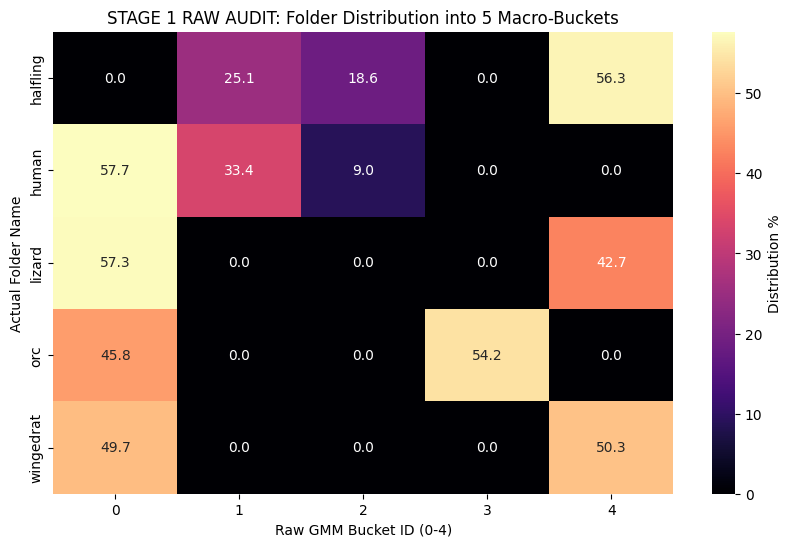


 STAGE 2: MICRO-CLUSTER PURITY & MATRICES

--- Analyzing Inside Macro-Bucket [0] ---
  Micro [ 0_0] Purity:  34.10% | Dominant Sheet: 'lizard_F' (297/871)
  Micro [ 0_1] Purity: 100.00% | Dominant Sheet: 'human_E' (246/246)
  Micro [0_10] Purity: 100.00% | Dominant Sheet: 'orc_K' (147/147)
  Micro [0_11] Purity: 100.00% | Dominant Sheet: 'lizard_G' (150/150)
  Micro [ 0_2] Purity:  67.26% | Dominant Sheet: 'lizard_C' (113/168)
  Micro [ 0_3] Purity:  40.74% | Dominant Sheet: 'orc_G' (55/135)
  Micro [ 0_4] Purity:  99.15% | Dominant Sheet: 'human_C' (232/234)
  Micro [ 0_5] Purity:  62.09% | Dominant Sheet: 'human_K' (267/430)
  Micro [ 0_6] Purity:  28.31% | Dominant Sheet: 'human_J' (248/876)
  Micro [ 0_7] Purity: 100.00% | Dominant Sheet: 'wingedrat_A' (285/285)
  Micro [ 0_8] Purity: 100.00% | Dominant Sheet: 'lizard_A' (24/24)
  Micro [ 0_9] Purity:  46.75% | Dominant Sheet: 'human_G' (36/77)


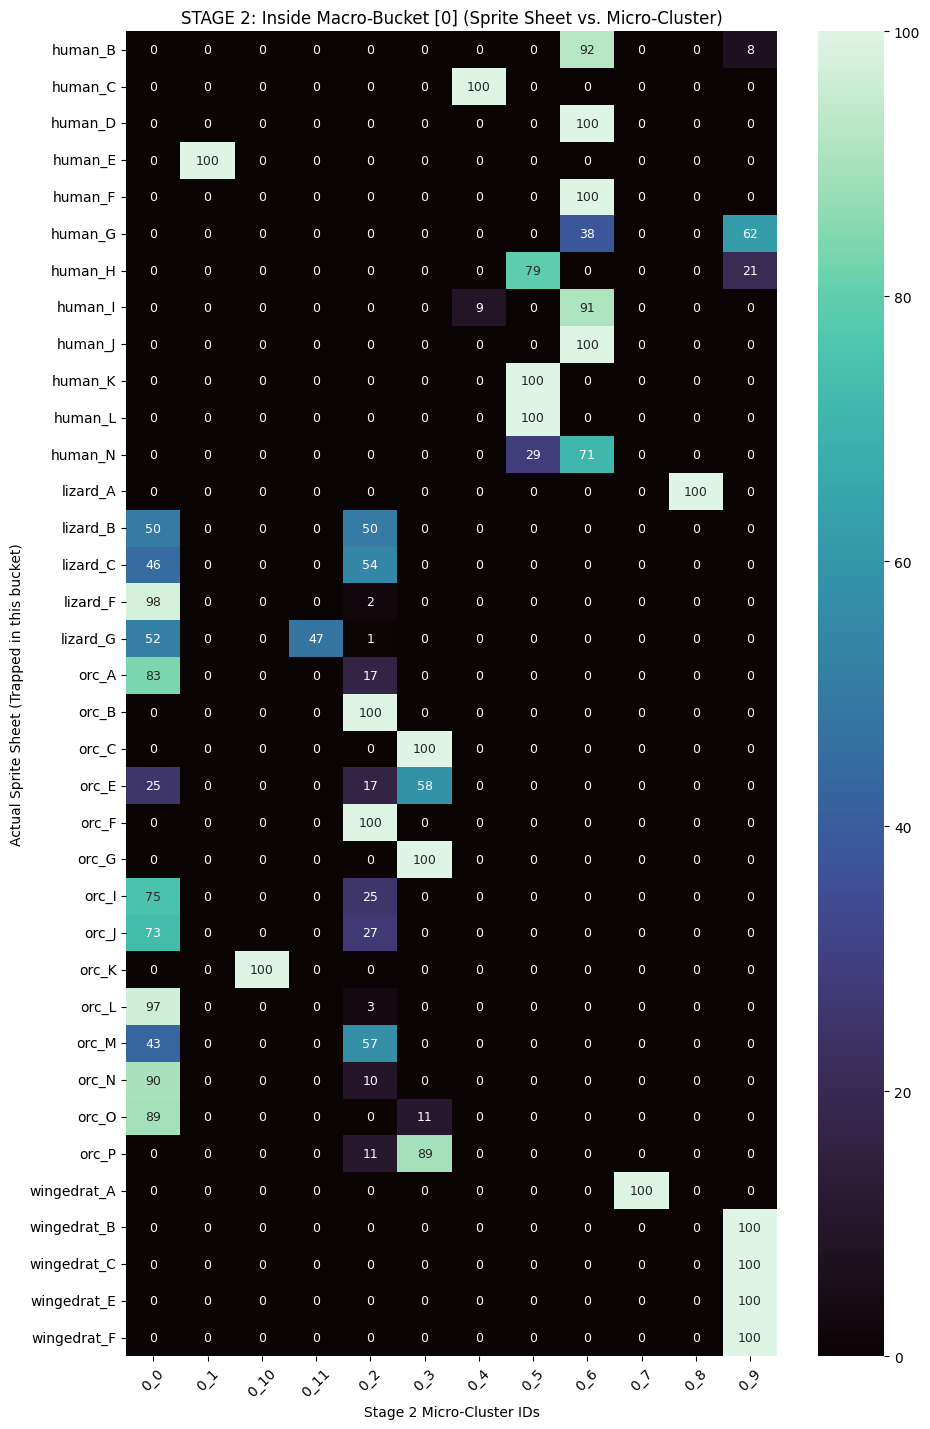


--- Analyzing Inside Macro-Bucket [1] ---
  Micro [ 1_0] Purity: 100.00% | Dominant Sheet: 'halfling_A' (164/164)
  Micro [ 1_1] Purity: 100.00% | Dominant Sheet: 'human_O' (354/354)
  Micro [ 1_2] Purity:  93.44% | Dominant Sheet: 'human_P' (342/366)
  Micro [ 1_3] Purity: 100.00% | Dominant Sheet: 'human_M' (354/354)
  Micro [ 1_4] Purity: 100.00% | Dominant Sheet: 'halfling_B' (169/169)


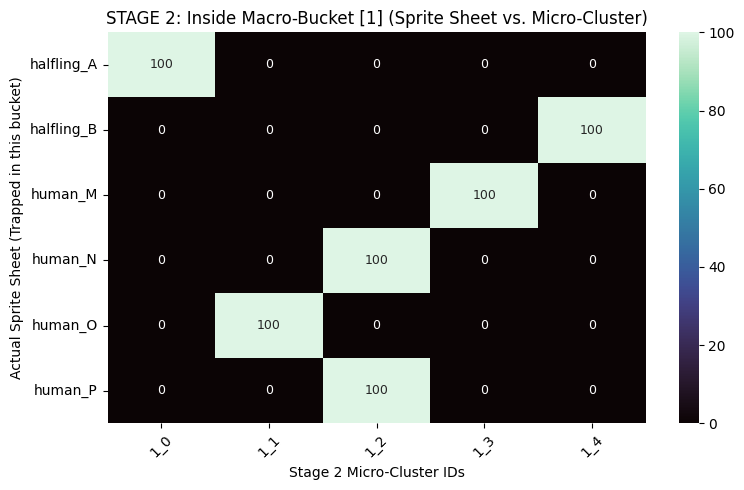


--- Analyzing Inside Macro-Bucket [2] ---
  Micro [ 2_0] Purity: 100.00% | Dominant Sheet: 'halfling_C' (246/246)
  Micro [ 2_1] Purity: 100.00% | Dominant Sheet: 'human_A' (289/289)


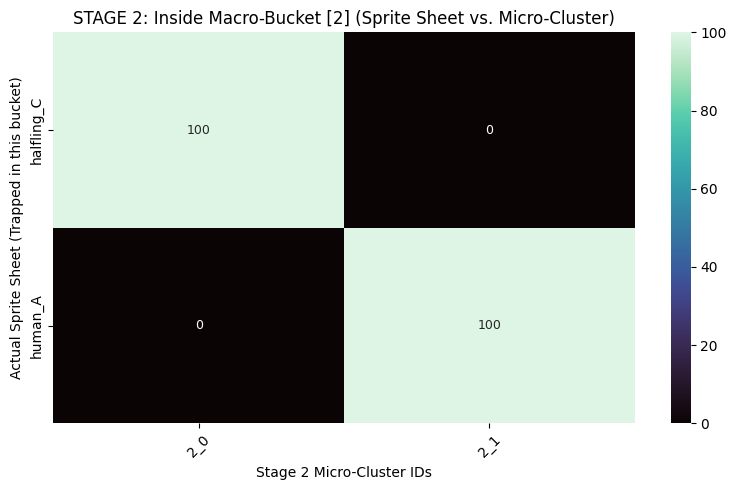


--- Analyzing Inside Macro-Bucket [3] ---
  Micro [ 3_0] Purity:  34.23% | Dominant Sheet: 'orc_F' (178/520)
  Micro [ 3_1] Purity:  89.13% | Dominant Sheet: 'orc_M' (205/230)


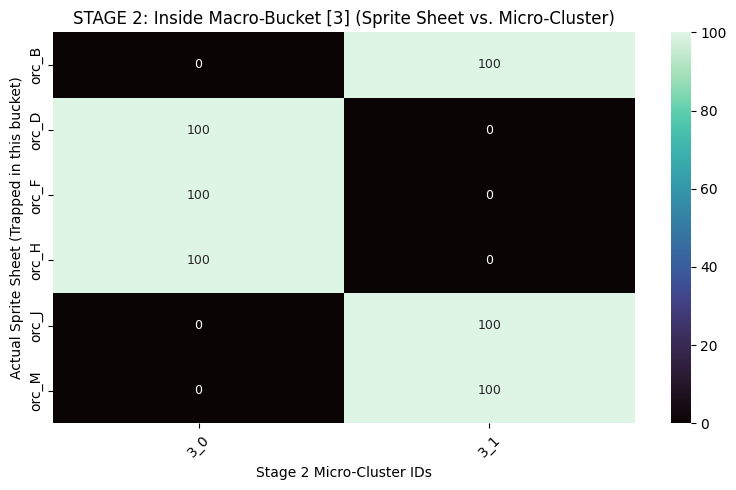


--- Analyzing Inside Macro-Bucket [4] ---
  Micro [ 4_0] Purity:  49.07% | Dominant Sheet: 'lizard_E' (315/642)
  Micro [ 4_1] Purity: 100.00% | Dominant Sheet: 'wingedrat_D' (294/294)
  Micro [ 4_2] Purity:  51.53% | Dominant Sheet: 'halfling_E' (253/491)
  Micro [ 4_3] Purity: 100.00% | Dominant Sheet: 'halfling_F' (256/256)


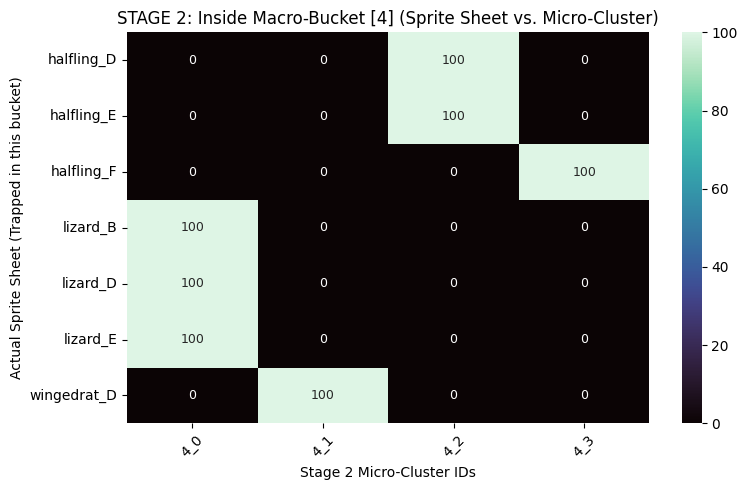

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot_pipeline(df):
    """Calculates Purity Accuracy and generates all heatmaps for the Unsupervised Pipeline."""
    
    # =========================================================
    # 1. STAGE 1: MACRO PURITY & DISTRIBUTION AUDIT
    # =========================================================
    print("\n" + "="*60)
    print(" STAGE 1: MACRO-BUCKET PURITY REPORT")
    print("="*60)
    
    macro_clusters = sorted(df['raw_pred_category'].unique())
    
    for macro_id in macro_clusters:
        subset = df[df['raw_pred_category'] == macro_id]
        if subset.empty: continue
        
        total_in_macro = len(subset)
        top_folder = subset['category'].mode()[0]
        top_folder_count = len(subset[subset['category'] == top_folder])
        purity = (top_folder_count / total_in_macro) * 100
        
        print(f"Bucket [{macro_id}] Purity: {purity:>6.2f}% | Dominant Species: '{top_folder}' ({top_folder_count}/{total_in_macro})")

    # Plot Stage 1 Macro Distribution Heatmap
    plt.figure(figsize=(10, 6))
    macro_dist = pd.crosstab(df['category'], df['raw_pred_category'], normalize='index') * 100
    sns.heatmap(macro_dist, annot=True, fmt=".1f", cmap="magma", cbar_kws={'label': 'Distribution %'})
    plt.title("STAGE 1 RAW AUDIT: Folder Distribution into 5 Macro-Buckets")
    plt.ylabel("Actual Folder Name")
    plt.xlabel("Raw GMM Bucket ID (0-4)")
    plt.show()

    # =========================================================
    # 2. STAGE 2: MICRO PURITY & INTERNAL MATRICES
    # =========================================================
    print("\n" + "="*60)
    print(" STAGE 2: MICRO-CLUSTER PURITY & MATRICES")
    print("="*60)
    
    for macro_id in macro_clusters:
        subset_df = df[df['raw_pred_category'] == macro_id]
        if subset_df.empty: continue
        
        print(f"\n--- Analyzing Inside Macro-Bucket [{macro_id}] ---")
        
        # Calculate Purity for Micro-Clusters inside this specific Macro-Bucket
        micro_clusters = sorted(subset_df['raw_pred_sub_category'].unique())
        for micro_id in micro_clusters:
            if micro_id == "-1": continue
            
            micro_subset = subset_df[subset_df['raw_pred_sub_category'] == micro_id]
            if micro_subset.empty: continue
                
            total_in_micro = len(micro_subset)
            top_sheet = micro_subset['sub_category'].mode()[0]
            top_sheet_count = len(micro_subset[micro_subset['sub_category'] == top_sheet])
            purity = (top_sheet_count / total_in_micro) * 100
            
            print(f"  Micro [{micro_id:>4}] Purity: {purity:>6.2f}% | Dominant Sheet: '{top_sheet}' ({top_sheet_count}/{total_in_micro})")

        # Plot Stage 2 Micro Matrix for this Macro-Bucket
        micro_dist = pd.crosstab(subset_df['sub_category'], subset_df['raw_pred_sub_category'])
        
        # Drop completely empty rows/cols to keep the heatmap clean
        micro_dist = micro_dist.loc[(micro_dist != 0).any(axis=1), (micro_dist != 0).any(axis=0)]
        
        if micro_dist.empty: continue
            
        micro_dist_pct = micro_dist.div(micro_dist.sum(axis=1), axis=0) * 100
        
        fig_height = max(5, len(micro_dist_pct) * 0.4) 
        fig_width = max(8, len(micro_dist_pct.columns) * 0.8)
        
        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(micro_dist_pct, annot=True, fmt=".0f", cmap="mako", annot_kws={"size": 9})
        plt.title(f"STAGE 2: Inside Macro-Bucket [{macro_id}] (Sprite Sheet vs. Micro-Cluster)")
        plt.ylabel("Actual Sprite Sheet (Trapped in this bucket)")
        plt.xlabel(f"Stage 2 Micro-Cluster IDs")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# ==========================================
# MASTER EXECUTION 
# ==========================================
if __name__ == "__main__":
    BASE_DIR = "./dungeon_images_colour80" 
    
    # 1. Multi-threaded Extraction
    raw_df = build_multithreaded_dataset(BASE_DIR)
    
    # 2. Mathematical Pipeline (Pure Unsupervised)
    final_df = run_quad_pipeline(raw_df)
    
    # 3. Master Evaluation (Purity Scores + All Heatmaps)
    evaluate_and_plot_pipeline(final_df)

---
## CAE

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import cv2

class SpriteCAE(nn.Module):
    def __init__(self, latent_dim=128, channels=3, img_size=64):
        super(SpriteCAE, self).__init__()
        
        self.img_size = img_size
        # Calculate the spatial size after 2 pooling layers (img_size / 4)
        self.conv_out_size = img_size // 4 
        
        # --- THE ENCODER (Compressor) ---
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * self.conv_out_size * self.conv_out_size, latent_dim)
        )
        
        # --- THE DECODER (Reconstructor) ---
        self.decoder_linear = nn.Sequential(
            nn.Linear(latent_dim, 64 * self.conv_out_size * self.conv_out_size),
            nn.ReLU()
        )
        
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid() # Forces pixel values between 0 and 1
        )

    def get_latent_features(self, x):
        """This is the crucial function: We only want the 128D fingerprint."""
        with torch.no_grad():
            return self.encoder(x)

    def forward(self, x):
        latent = self.encoder(x)
        x = self.decoder_linear(latent)
        x = x.view(-1, 64, self.conv_out_size, self.conv_out_size) 
        reconstruction = self.decoder_conv(x)
        return reconstruction

In [8]:
def extract_deep_features(df, base_dir, epochs=15, batch_size=64, img_size=64):
    print("Preparing Image Tensors for Deep Learning...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    # 1. Load and Preprocess all images
    # We load them freshly from disk to ensure they are full RGB arrays, not the extracted LBP/Hu features
    images = []
    for path in df['file_path']: # Ensure your dataframe has the full file paths
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        # PyTorch expects Channels-First format (C, H, W) and normalized floats (0 to 1)
        img = np.transpose(img, (2, 0, 1)).astype(np.float32) / 255.0
        images.append(img)
        
    X_tensor = torch.tensor(np.array(images)).to(device)
    dataset = TensorDataset(X_tensor, X_tensor) # Autoencoder targets itself
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # 2. Initialize the Model
    model = SpriteCAE(latent_dim=128, channels=3, img_size=img_size).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # 3. Train the Autoencoder
    print(f"Training Autoencoder for {epochs} epochs...")
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_features, _ in dataloader:
            optimizer.zero_grad()
            outputs = model(batch_features)
            loss = criterion(outputs, batch_features)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss/len(dataloader):.4f}")

    # 4. Extract the Bottleneck (Latent Features)
    print("Extracting 128D Latent Fingerprints...")
    model.eval()
    
    # Process in batches to prevent memory crashes on 8,000+ images
    extract_loader = DataLoader(TensorDataset(X_tensor), batch_size=256, shuffle=False)
    all_latents = []
    
    for batch in extract_loader:
        batch_data = batch[0]
        latent_vectors = model.get_latent_features(batch_data)
        all_latents.append(latent_vectors.cpu().numpy())
        
    # Stack them into a single continuous array
    fused_deep_features = np.vstack(all_latents)
    
    # Store them back into the dataframe as a new column
    df['deep_features'] = list(fused_deep_features)
    
    print("Deep Feature Extraction Complete!")
    return df

In [9]:
import umap
import hdbscan
import pandas as pd
import numpy as np

def run_deep_pipeline(df, latent_features):
    """Executes UMAP reduction and Single-Stage HDBSCAN clustering."""
    print("Crushing 128D Deep Features with UMAP...")
    
    # 1. UMAP pushes similar sprites into incredibly tight clusters
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.01, n_components=3, random_state=47)
    umap_embeddings = reducer.fit_transform(latent_features)
    
    # 2. HDBSCAN finds the natural Micro-Clusters (The individual sprite sheets)
    print("Sweeping for dense islands with HDBSCAN...")
    # min_cluster_size is the minimum number of frames required to call it a "Sprite Sheet"
    clusterer = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5, cluster_selection_epsilon=0.5)
    
    # We directly assign the HDBSCAN output to the sub_category
    df['raw_pred_sub_category'] = clusterer.fit_predict(umap_embeddings)
    
    total_islands = len(df['raw_pred_sub_category'].unique()) - (1 if -1 in df['raw_pred_sub_category'].values else 0)
    print(f"HDBSCAN found {total_islands} distinct sprite islands (Micro-clusters)!")
    print(f"Noise detected (Unclustered sprites): {(df['raw_pred_sub_category'] == -1).sum()}")

    # 3. The "Roll-Up" (Assigning Macro Labels)
    print("Rolling up Micro-Clusters into Macro-Categories...")
    df['pred_category'] = "Unassigned"
    
    # We map each HDBSCAN island to the 5 human folders based on what's inside it
    for cluster_id in df['raw_pred_sub_category'].unique():
        if cluster_id == -1:
            df.loc[df['raw_pred_sub_category'] == -1, 'pred_category'] = "Noise"
            continue
            
        # Look at what is inside this specific island
        island_contents = df[df['raw_pred_sub_category'] == cluster_id]
        
        # What is the most common actual folder in this island?
        winning_macro = island_contents['category'].mode()[0]
        
        # Assign that folder name to the entire island
        df.loc[df['raw_pred_sub_category'] == cluster_id, 'pred_category'] = winning_macro

    final_cols = ['image_name', 'category', 'sub_category', 'pred_category', 'raw_pred_sub_category']
    return df[final_cols]